# Pump, Resistance, timeline screening, and Permeability Processing

A processing recipe for the configured pump and resistance data roots, with pump-derived flow rates used for permeability review.

## Run order

1. Run the configuration and inventory cells to resolve the pump, resistance, and configured output locations.
2. Load and combine the pump text exports, then review the effective radial stress plot.
3. Load, format, and review the averaged resistance exports; optionally write the combined table.
4. Optionally write the combined pump table.
5. Add flow-rate columns, review pressure/volume plots, and define the permeability windows.
6. Calculate and plot permeability for the selected windows.

Resistance measurements are formatted and reviewed independently of the pump-derived permeability calculations.


In [27]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
project_root = next(
    (candidate for candidate in (working_directory, *working_directory.parents) if (candidate / "pyproject.toml").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from within the basalt-processing project.")

source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from basalt_processing.paths import load_config, resolve_path

CONFIG_PATH = project_root / "config" / "basalt.example.toml"
config = load_config(CONFIG_PATH)
paths_config = config.get("paths", {})
data_root = resolve_path(paths_config["data_root"], config.get("_config_dir"))
ct_raw_root = resolve_path(paths_config["ct_raw"], data_root)
ct_processed_root = resolve_path(paths_config["ct_processed"], data_root)
pump_root = resolve_path(paths_config["pump"], data_root)
resistance_root = resolve_path(paths_config["resistance"], data_root)
output_root = resolve_path(paths_config["output"], data_root)
data_root, ct_raw_root, ct_processed_root, pump_root, resistance_root, output_root


In [28]:
import numpy as np
import pandas as pd
import importlib
from basalt_processing.pump import load_pump_file, write_pump_outputs
from basalt_processing.ct_inventory import build_ct_datetime_table
import basalt_processing.resistance as resistance
importlib.reload(resistance)
from basalt_processing.resistance import load_resistance_folder, write_resistance_outputs
from basalt_processing.resistance import clean_resistance_folder, write_resistivity_pickles

pump_filepaths = sorted(pump_root.rglob("*.txt")) if pump_root.exists() else []
resistance_filepaths = sorted(resistance_root.rglob("*.csv")) if resistance_root.exists() else []
print(f"Pump text exports: {len(pump_filepaths)} under {pump_root}")
print(f"Resistance CSV exports: {len(resistance_filepaths)} under {resistance_root}")


## Load and review pump data

The pump reader skips instrument metadata rows and creates a parsed `datetime` column. The next cell combines all discovered pump exports in chronological order.

In [29]:
FLOW_VOLUME_COLUMNS = ["A21 GDSMiddle_Eng", "GDS Perm Volume A_Eng"]


In [30]:
if not pump_filepaths:
    raise FileNotFoundError(f"No pump text exports found under {pump_root}")

df = pd.concat([load_pump_file(path) for path in pump_filepaths], ignore_index=True)
df["datetime"] = pd.to_datetime(df["Time"], format="%d:%m:%Y %H:%M:%S.%f")
df = df.sort_values(by="datetime")
df = df.reset_index(drop=True)
df["time"] = (df["datetime"] - df["datetime"].iloc[0]) / pd.Timedelta(hours=1)

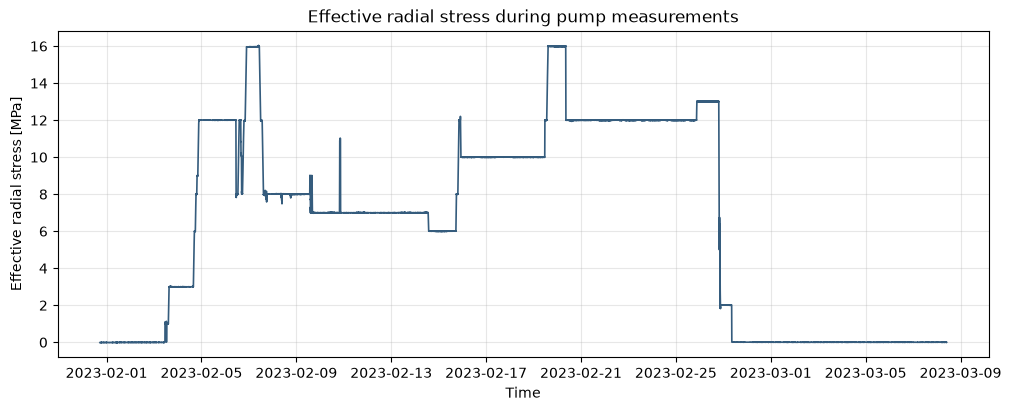

In [31]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(df["datetime"], df["B24   Effective Radial Stress_Calc"], color="#355C7D", linewidth=1.2)
ax.set_title("Effective radial stress during pump measurements")
ax.set_xlabel("Time")
ax.set_ylabel("Effective radial stress [MPa]")
ax.grid(True, alpha=0.3)
plt.show()


In [32]:
RUN_PUMP_EXPORT = False
output_stem = output_root / "pump" / "mechanical"
if RUN_PUMP_EXPORT:
    write_pump_outputs(df, output_stem)
    print(f"Wrote {output_stem.with_suffix('.csv')} and {output_stem.with_suffix('.xlsx')}")
else:
    print("Set RUN_PUMP_EXPORT = True to write combined pump outputs.")


Set RUN_PUMP_EXPORT = True to write combined pump outputs.


## Load, format, and review resistance data

The configured resistance root contains averaged exports at several measurement frequencies. The reader automatically recognises the current comma-delimited `Timestamp` format as well as older semicolon-delimited `Date`/`Time` files. It retains each source `filename` and folder so the merged table remains traceable.

Only the averaged `*Hz_avg_combined.csv` exports are selected below. For each frequency, the cleaning follows the timeline calculation from notebook 07: calculate `rho_Ch1` from `R_Ch1`, create elapsed `time` relative to the first pump measurement, and retain data from 72 hours onwards. Resistance formatting is independent of the pump data used for the permeability calculation.

Set `RUN_TIMELINE_PICKLE_EXPORT` to write `mechanical.pkl`, `CT_datetimes.pkl`, the combined `resistivity.pkl`, and an individual `resistivity_<frequency>hz.pkl` file for each measurement frequency into the configured output root. CT dates come from processed-folder names and kV comes from each raw scan’s `.xtekct` `XraykV` field. These are the pump/resistance/CT inputs required by the timeline notebook.


In [33]:
RESISTANCE_PATTERN = "*Hz_avg_combined.csv"
RESISTANCE_MIN_TIME_HOURS = 72

if not resistance_filepaths:
    raise FileNotFoundError(f"No resistance CSV exports found under {resistance_root}")

resistivity_by_frequency = clean_resistance_folder(
    resistance_root,
    reference_datetime=df["datetime"].iloc[0],
    min_time_hours=RESISTANCE_MIN_TIME_HOURS,
    pattern=RESISTANCE_PATTERN,
)
resistance_df = pd.concat(resistivity_by_frequency.values(), ignore_index=True).sort_values("datetime").reset_index(drop=True)
frequencies_hz = sorted(resistivity_by_frequency)
print(f"Loaded {len(resistance_df):,} cleaned rows at {frequencies_hz} Hz.")
resistance_df.head()


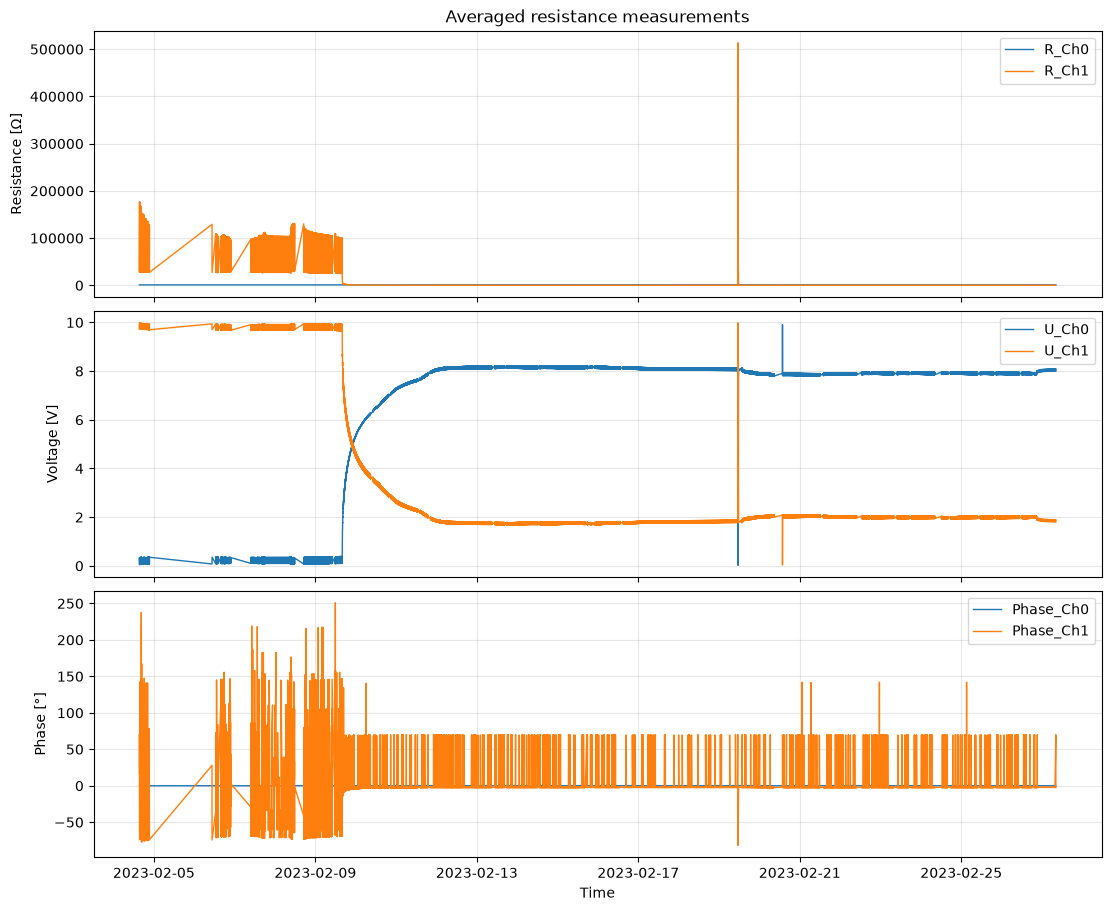

In [34]:
# Resistance channels are plotted by quantity so their different units remain readable.
channel_groups = {
    "Resistance [Ω]": [column for column in resistance_df if column.startswith("R_")],
    "Voltage [V]": [column for column in resistance_df if column.startswith("U_")],
    "Phase [°]": [column for column in resistance_df if column.startswith("Phase_")],
}
channel_groups = {label: columns for label, columns in channel_groups.items() if columns}
if not channel_groups:
    raise ValueError("No R_, U_, or Phase_ resistance channels were found.")

fig, axes = plt.subplots(len(channel_groups), 1, figsize=(11, 3 * len(channel_groups)), sharex=True, layout="constrained")
for ax, (label, columns) in zip(np.atleast_1d(axes), channel_groups.items()):
    for column in columns:
        ax.plot(resistance_df["datetime"], resistance_df[column], linewidth=1.0, label=column)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes = np.atleast_1d(axes)
axes[0].set_title("Averaged resistance measurements")
axes[-1].set_xlabel("Time")
plt.show()


In [35]:
RUN_RESISTANCE_EXPORT = False
resistance_output_stem = output_root / "resistance" / "averaged_measurements"
if RUN_RESISTANCE_EXPORT:
    write_resistance_outputs(resistance_df, resistance_output_stem)
    print(f"Wrote {resistance_output_stem.with_suffix('.csv')} and {resistance_output_stem.with_suffix('.xlsx')}")
else:
    print("Set RUN_RESISTANCE_EXPORT = True to write formatted resistance outputs.")


Set RUN_RESISTANCE_EXPORT = True to write formatted resistance outputs.


In [36]:

RUN_TIMELINE_PICKLE_EXPORT = True
if RUN_TIMELINE_PICKLE_EXPORT:
    mechanical_path = output_root / "mechanical.pkl"
    mechanical_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(mechanical_path)
    resistivity_paths = write_resistivity_pickles(resistivity_by_frequency, output_root)
    ct_datetimes_path = output_root / "CT_datetimes.pkl"
    ct_datetime_data = build_ct_datetime_table(ct_processed_root, ct_raw_root)
    ct_datetime_data.to_pickle(ct_datetimes_path)
    print(f"Wrote {mechanical_path}")
    print(f"Wrote {ct_datetimes_path}")
    for label, path in resistivity_paths.items():
        print(f"Wrote {label}: {path}")
else:
    print("Set RUN_TIMELINE_PICKLE_EXPORT = True to write individual timeline input pickles.")


In [37]:
from basalt_processing.permeability import add_flow_rate_columns, calculate_permeability

df = add_flow_rate_columns(df, FLOW_VOLUME_COLUMNS)



## Flow, pressure, and permeability review

The command-line tools can be run from the project root when a notebook is not required:

```powershell
uv run basalt-process-pump path\to\pump-1.txt path\to\pump-2.txt --output output\pump
uv run basalt-process-resistance path\to\resistance --pattern "*Hz_avg_combined.csv" --output output\resistance
uv run basalt-process-permeability output\pump.csv --volume-columns "A21 GDSMiddle_Eng" "GDS Perm Volume A_Eng" --output output\permeability.csv
```

### Flow-rate columns

For each cumulative-volume channel, `rate` is the cumulative-volume difference divided by elapsed seconds. `rate_smooth` is a centred 10-sample moving average of that instantaneous rate; the shorter edge windows use the samples available. The signed rates are retained for the time-series plots. `mean_flow_rate`, used for the Darcy calculation, is the mean of the absolute smoothed rates from the two flow channels.

### Permeability windows

The shaded intervals are the broader permeability tests. The calculation windows are the stable sub-intervals selected within them. Review the raw pressure and flow plots first, then adjust the timestamp lists only when the interval has stable flow and pressure behaviour.

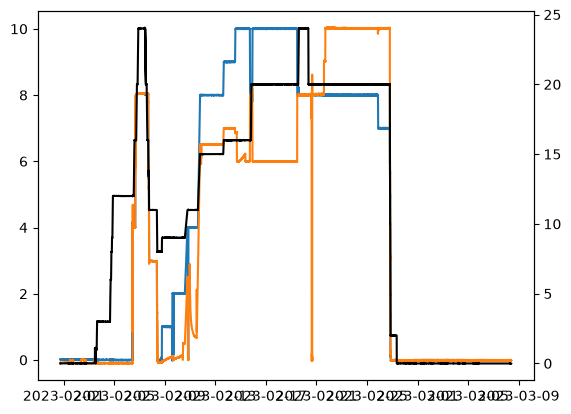

In [38]:
# plot the pore pressure data
f, ax = plt.subplots()
ax.plot(
    df["datetime"].values,
    df["B4    Pore Pressure Bottom  PP1_Calc"].values,
    label="Bottom PP1",
)
ax.plot(
    df["datetime"].values,
    df["B2    Pore Pressure Top  PP2_Calc"].values,
    label="Top PP2",
)

ax1 = ax.twinx()
ax1.plot(
    df["datetime"].values,
    df["B1    Cell Pressure_Calc"].values,
    label="Top PP2",
    color="k",
)
plt.show()

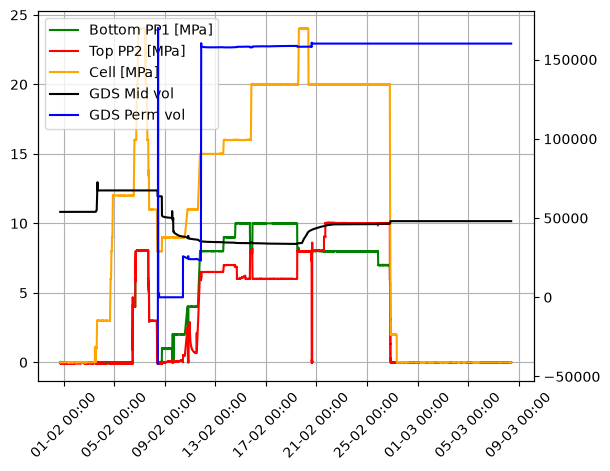

In [39]:
import matplotlib.dates as mdates

# plot the pore pressure data
f, ax = plt.subplots()
ax.plot(df['datetime'].values, df['B4    Pore Pressure Bottom  PP1_Calc'].values, label='Bottom PP1 [MPa]', color='g')
ax.plot(df['datetime'].values, df['B2    Pore Pressure Top  PP2_Calc'].values, label='Top PP2 [MPa]', color='r')
ax.plot(df['datetime'].values, df['B1    Cell Pressure_Calc'].values, label='Cell [MPa]', color='orange')

ax1 = ax.twinx()
ax1.plot(df['datetime'].values, df['A21 GDSMiddle_Eng'].values, label='GDS Mid vol', color='k')
ax1.plot(df['datetime'].values, df['GDS Perm Volume A_Eng'].values, label='GDS Perm vol', color='b')

# Set the x-axis to show month, day, and time
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

# Rotate x-axis labels for better visibility
for label in ax.get_xticklabels():
    label.set_rotation(45)


# Get lines and labels from both axes
lines = ax.lines + ax1.lines
labels = [line.get_label() for line in lines]

# Create a single legend for all lines from both axes
ax.legend(lines, labels, loc='upper left')

ax.grid()

plt.show()

In [40]:
required_rate_columns = [f"{column}_rate_smooth" for column in FLOW_VOLUME_COLUMNS]
missing_rate_columns = [column for column in required_rate_columns if column not in df]
if missing_rate_columns:
    raise RuntimeError(f"Run the flow-rate cell first; missing {missing_rate_columns}.")


In [41]:
# mean flow rate for permeability calculation
df["mean_flow_rate"] = (df["GDS Perm Volume A_Eng_rate_smooth"].abs() + df["A21 GDSMiddle_Eng_rate_smooth"].abs())/2

# pressure gradient for permability calculation
df["pressure_differential"] = np.abs(df["B4    Pore Pressure Bottom  PP1_Calc"].abs() - df["B2    Pore Pressure Top  PP2_Calc"])

In [42]:
# Permeability timestamps
from datetime import datetime

datetime_perm = [
    ("23-02-11 19:00", "23-02-13 14:00"),
    ("23-02-13 15:55", "23-02-14 13:00"),
    ("23-02-14 16:50", "23-02-15 17:00"),
    ("23-02-15 23:00", "23-02-19 11:00"),
]
datetime_perm_calc = [
    ("23-02-12 15:00", "23-02-13 14:00"),
    ("23-02-13 19:45", "23-02-14 13:00"),
    ("23-02-15 10:00", "23-02-15 17:00"),
    ("23-02-17 12:00", "23-02-19 11:00"),
]
effective_stress = [7.75, 8, 8, 12]


def parse_windows(windows):
    return [
        (datetime.strptime(start, "%y-%m-%d %H:%M"), datetime.strptime(stop, "%y-%m-%d %H:%M"))
        for start, stop in windows
    ]


datetime_tuples = parse_windows(datetime_perm)
datetime_tuples_calc = parse_windows(datetime_perm_calc)


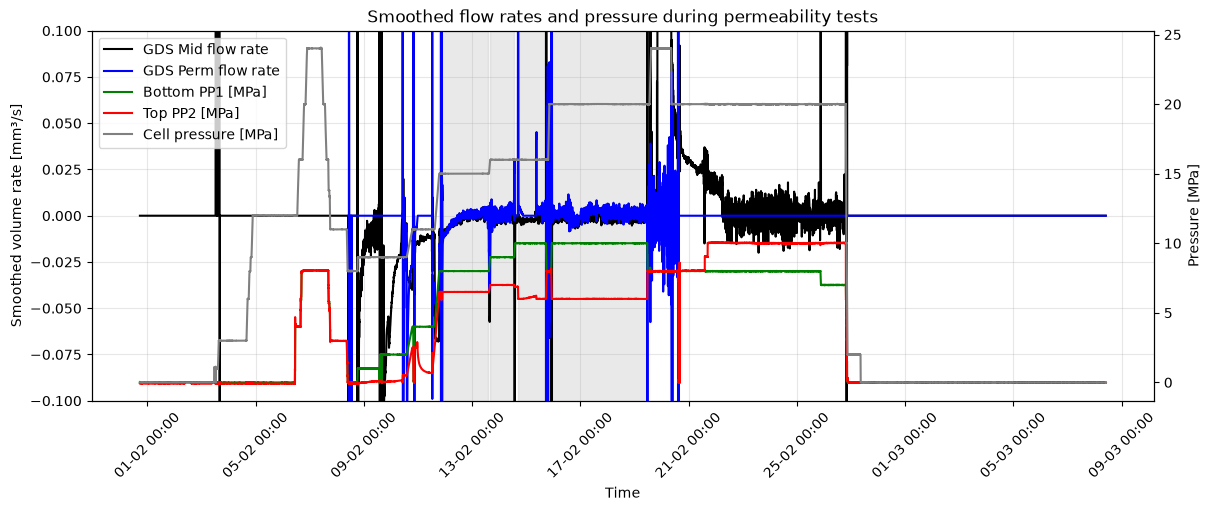

In [43]:
# Review signed flow rates and pressure during the broader permeability tests.
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")

# ax.plot(df['datetime'].values, df['A21 GDSMiddle_Eng_rate'].values, label='GDS Mid flow rate', color='k')
# ax.plot(df['datetime'].values, df['GDS Perm Volume A_Eng_rate'].values, label='GDS Perm flow rate', color='b')

ax.plot(
    df["datetime"].values,
    df["A21 GDSMiddle_Eng_rate_smooth"].values,
    label="GDS Mid flow rate",
    color="k",
)
ax.plot(
    df["datetime"].values,
    df["GDS Perm Volume A_Eng_rate_smooth"].values,
    label="GDS Perm flow rate",
    color="b",
)

# Add shaded regions for each datetime tuple
for index, (start, stop) in enumerate(datetime_tuples):
    ax.axvspan(start, stop, color="#A9A9A9", alpha=0.25, label="Permeability test" if index == 0 else None)

# Set the x-axis to show month, day, and time
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))

ax1 = ax.twinx()
ax1.plot(
    df["datetime"].values,
    df["B4    Pore Pressure Bottom  PP1_Calc"].values,
    label="Bottom PP1 [MPa]",
    color="g",
)
ax1.plot(
    df["datetime"].values,
    df["B2    Pore Pressure Top  PP2_Calc"].values,
    label="Top PP2 [MPa]",
    color="r",
)

ax1.plot(
    df["datetime"].values,
    df["B1    Cell Pressure_Calc"].values,
    label="Cell pressure [MPa]",
    color="gray",
)

# Rotate x-axis labels for better visibility
for label in ax.get_xticklabels():
    label.set_rotation(45)

# Get lines and labels from both axes
lines = ax.lines + ax1.lines
labels = [line.get_label() for line in lines]

# Create a single legend for all lines from both axes
ax.legend(lines, labels, loc="upper left")

ax.set_ylim(-0.1, 0.1)
ax.set_title("Smoothed flow rates and pressure during permeability tests")
ax.set_xlabel("Time")
ax.set_ylabel("Smoothed volume rate [mm³/s]")
ax1.set_ylabel("Pressure [MPa]")
ax.grid(True, alpha=0.3)
plt.show()



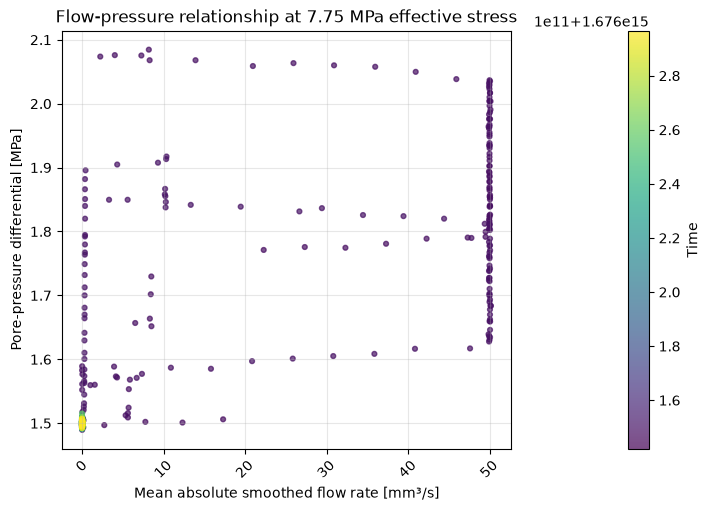

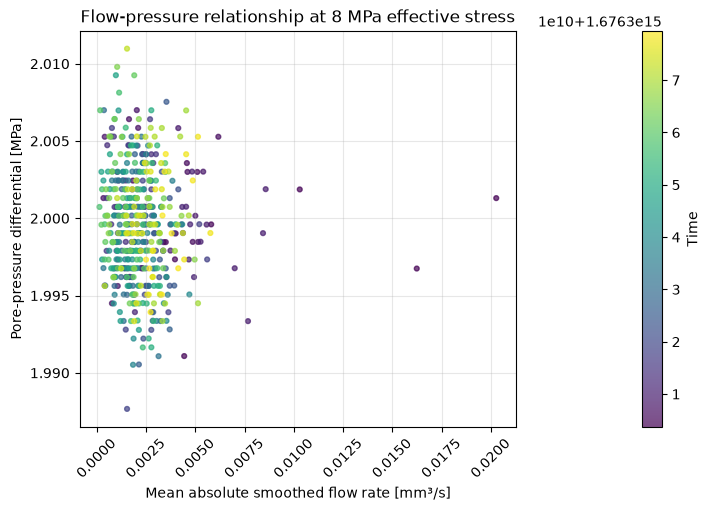

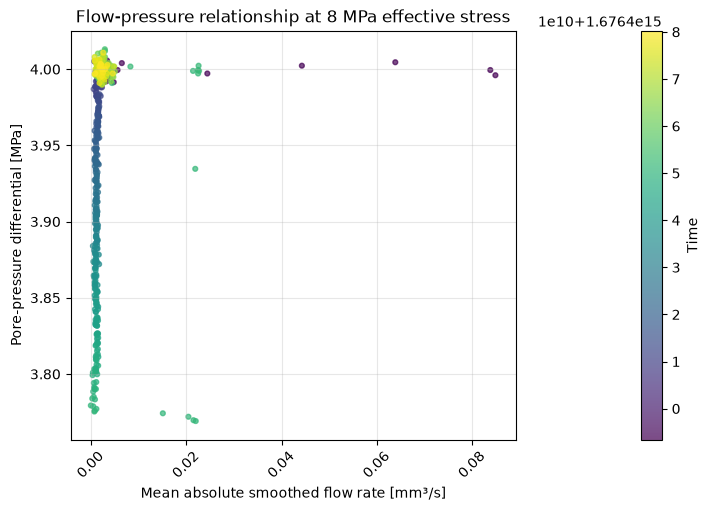

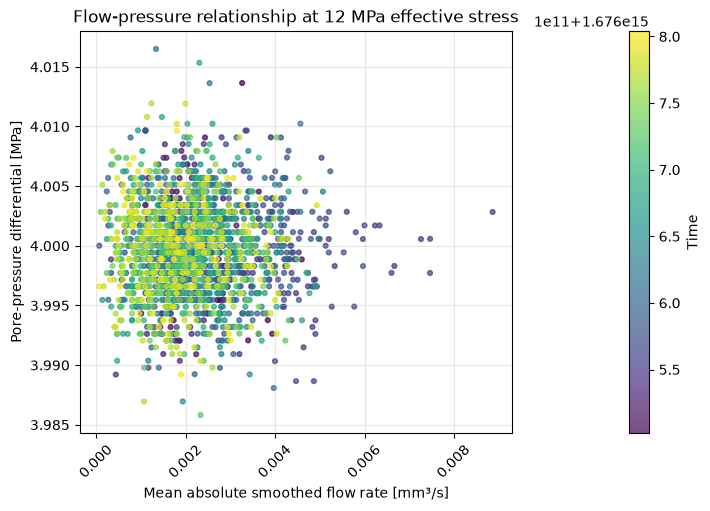

In [44]:
# Inspect the flow-pressure relationship within each broader permeability test.

for dt_tuple, ef in zip(datetime_tuples, effective_stress):

    _df = df[(df['datetime'] >= dt_tuple[0]) & (df['datetime'] <= dt_tuple[1])]

    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")

    # ax.plot(df['datetime'].values, df['A21 GDSMiddle_Eng_rate'].values, label='GDS Mid flow rate', color='k')
    # ax.plot(df['datetime'].values, df['GDS Perm Volume A_Eng_rate'].values, label='GDS Perm flow rate', color='b')

    sc = ax.scatter(
        _df["mean_flow_rate"].values,
        _df["pressure_differential"].values,
        marker="o",  # Marker style
        s=12,
        alpha=0.7,
        c=_df["datetime"].values,  # Color based on another column
        cmap="viridis"  # Color map (optional)
    )

    # Rotate x-axis labels for better visibility
    for label in ax.get_xticklabels():
        label.set_rotation(45)

    plt.colorbar(sc, ax=ax, label='Time')

    # Get lines and labels from both axes
    lines = ax.lines
    labels = [line.get_label() for line in lines]

    # Create a single legend for all lines from both axes
    #ax.legend(lines, labels, loc="upper left")

    ax.set_title(f"Flow-pressure relationship at {ef} MPa effective stress")
    ax.set_xlabel("Mean absolute smoothed flow rate [mm³/s]")
    ax.set_ylabel("Pore-pressure differential [MPa]")
    ax.grid(True, alpha=0.3)
    plt.show()

## Permeability calculation

For each stable window, the notebook calculates cylindrical-sample permeability from Darcy's law using mean flow rate and mean pore-pressure difference. Confirm the specimen dimensions, fluid viscosity, pressure units, and window bounds before interpreting the results.

In [45]:
Q = 0.002e-9  # m³/s, converted from mm³/s
mu = 1.09e-3  # dynamic viscosity in Pa·s; confirm for the test fluid
d = 25.2e-3  # specimen diameter in m
h = 40e-3  # specimen length in m
P1 = 10e6  # upstream pressure in Pa
P2 = 6e6  # downstream pressure in Pa

permeability = calculate_permeability(Q, mu, d, h, P1, P2)
print(f"Permeability: {permeability:.2e} m^2")

Permeability: 4.37e-20 m^2


In [46]:
permeability = []
pp_gradient = []
queues = []
pp1_values = []
pp2_values = []

for dt_tuple in datetime_tuples_calc:

    _df = df[(df['datetime'] >= dt_tuple[0]) & (df['datetime'] <= dt_tuple[1])]

    PP1 = 1e6 *_df["B4    Pore Pressure Bottom  PP1_Calc"].mean()
    PP2 = 1e6 * _df["B2    Pore Pressure Top  PP2_Calc"].mean()

    Q = 1e-9 * _df["mean_flow_rate"].mean() 


    mu = 1.09e-3  # dynamic viscosity Pa.s
    d = 25.2e-3  # m
    h = 40e-3  # m

    queues.append(Q)
    pp1_values.append(PP1)
    pp2_values.append(PP2)

    pp_gradient.append(PP1 - PP2)
    permeability.append(calculate_permeability(Q, mu, d, h, PP1, PP2))

print(permeability) # m^2
print(queues) # m^3/s
print([pp/1e6 for pp in pp_gradient]) # MPa
print([pp/1e6 for pp in pp1_values]) # MPa
print([pp/1e6 for pp in pp2_values]) # MPa


[np.float64(7.96827714647954e-20), np.float64(9.295937861202246e-20), np.float64(5.114322518348784e-20), np.float64(4.30992557642083e-20)]
[np.float64(1.3673447456617778e-12), np.float64(2.1261266505636457e-12), np.float64(2.3401851190478946e-12), np.float64(1.9719223404255234e-12)]
[np.float64(1.500061695839161), np.float64(1.999362055314009), np.float64(3.9999782310714256), np.float64(3.999590818634751)]
[np.float64(8.000251965664336), np.float64(8.999835988285025), np.float64(10.000274514464284), np.float64(9.99980096699468)]
[np.float64(6.5001902698251754), np.float64(7.000473932971015), np.float64(6.000296283392858), np.float64(6.000210148359929)]


In [47]:
# Convert permeability from m² to mD
permeability_md = [perm * 1/(9.869233e-16) for perm in permeability]
print(permeability_md)  # mD

[np.float64(8.073856546379581e-05), np.float64(9.419108720203733e-05), np.float64(5.182087116951017e-05), np.float64(4.3670319430302535e-05)]


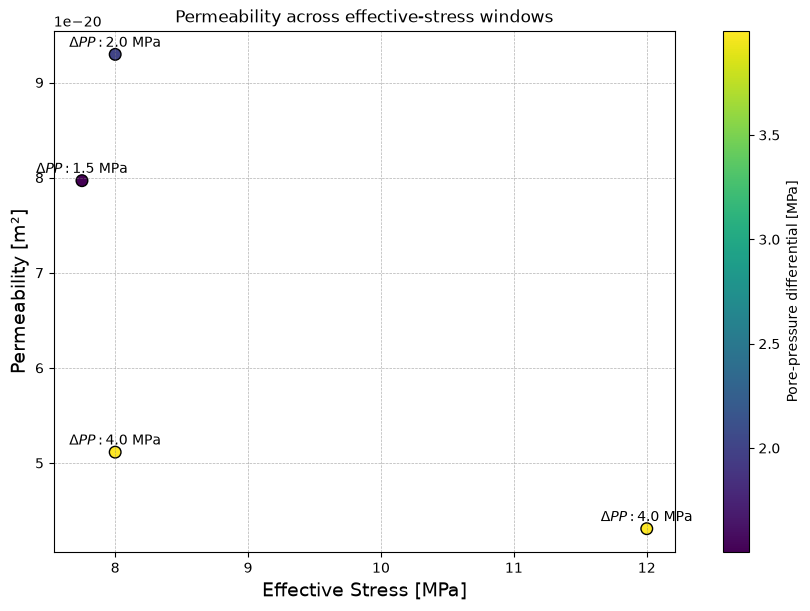

In [48]:
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")

pp_gradient_mpa = np.array(pp_gradient)/1e6

# Plot data with improved markers
scatter = ax.scatter(effective_stress, permeability, c=pp_gradient_mpa, cmap="viridis", marker="o", edgecolors="k", s=70)
fig.colorbar(scatter, ax=ax, label="Pore-pressure differential [MPa]")

# Annotate each point with its corresponding pp_gradient_mpa value
for i, txt in enumerate(pp_gradient_mpa):
    ax.annotate(rf"$\Delta PP:${txt:.1f} MPa", (effective_stress[i], permeability[i]), textcoords="offset points", xytext=(0, 5), ha='center')

# Add titles and labels
ax.set_title("Permeability across effective-stress windows")
ax.set_xlabel('Effective Stress [MPa]', fontsize=14)
ax.set_ylabel('Permeability [m²]', fontsize=14)

# Formatting the y-axis to scientific notation
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Add a grid for easier reading of plot
ax.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.6)

# Add a legend
#ax.legend(loc='upper right', fontsize=12)

# Show the plot
plt.show()